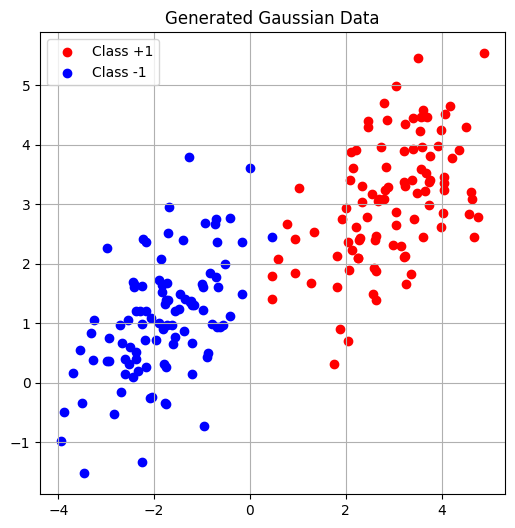

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# 2 sınıflı 2B (2 boyutlu) Gauss dağılımlı veri üretimi
np.random.seed(0)  # Rastgelelik sabitleniyor; her çalıştırmada aynı veri elde edilir

n_samples = 100  # Her sınıf için 100 örnek (toplam 200 veri noktası)
mean1 = [3, 3]   # 1. sınıfın ortalaması (x, y)
mean2 = [-2, 1] # 2. sınıfın ortalaması (x, y)
cov = [[1, 0.5], [0.5, 1]]  # Kovaryans matrisi (2x2): x ve y arasındaki ilişkiyi gösterir

# Her biri (100 x 2) boyutunda iki sınıf verisi üretiliyor
X1 = np.random.multivariate_normal(mean1, cov, n_samples)  # Sınıf +1 verileri
X2 = np.random.multivariate_normal(mean2, cov, n_samples)  # Sınıf -1 verileri

# Sınıf etiketleri: +1 ve -1
y1 = np.ones(n_samples)       # (100,)
y2 = -np.ones(n_samples)      # (100,)

# İki sınıf birleştiriliyor
X = np.vstack((X1, X2))       # (200 x 2): tüm örnekler bir arada
y = np.hstack((y1, y2))       # (200,): etiket vektörü

# 📊 Veriyi görselleştir
plt.figure(figsize=(6,6))
plt.scatter(X1[:,0], X1[:,1], c='r', label='Class +1')
plt.scatter(X2[:,0], X2[:,1], c='b', label='Class -1')
plt.title("Generated Gaussian Data")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# PyTorch tensörleri ve autograd ile model oluşturup eğitme
# Her epoch sonunda kayıp, ağırlık ve bias değerlerini izlemek için global listeler tanımlanıyor.
global losses_torch
losses_torch = []

# 4️⃣ PyTorch ile Perceptron (autograd + optimizasyon)
# Numpy dizileri torch tensörlerine dönüştürülüyor
X_t = torch.tensor(X, dtype=torch.float32)         # (200 x 2)
y_t = torch.tensor(y, dtype=torch.float32).view(-1, 1)  # (200 x 1)

# Ağırlıklar (2x1) ve bias (1x1) olarak tanımlanıyor, gradyan takibi aktif
w_t = torch.randn((2, 1), requires_grad=True)  # Normal dağılımdan rastgele başlatma
b_t = torch.randn(1, requires_grad=True)       # Bias için rastgele başlatma

# SGD (Stochastic Gradient Descent) optimizasyonu
# optimize edilmesi gereken parametreler: w_t ve b_t
optimizer = torch.optim.SGD([w_t, b_t], lr=0.01)

for epoch in range(10):
    optimizer.zero_grad()  # Gradyanları sıfırla (her backward sonrası birikir)

    # 🔹 İleri geçiş (forward pass)
    # Model çıktısı: X_t (200x2) @ w_t (2x1) + b_t (1,) → (200x1)
    y_pred = X_t @ w_t + b_t

    # 🔹 Kayıp fonksiyonu (perceptron loss)
    # max(0, -y_i * (w·x_i + b)) formülünün ortalaması
    loss = torch.mean(torch.clamp(-y_t * y_pred, min=0))

    # 🔹 Geri yayılım (backpropagation)
    loss.backward()  # w_t.grad ve b_t.grad değerleri otomatik hesaplanır

    # 🔹 Ağırlık güncellemesi
    optimizer.step()  # w_t ve b_t = w_t - lr * grad(w_t)
    
    # Kayıp, ağırlık ve bias değerlerini kaydet
    losses_torch.append(loss.item())

    
    print(f"Epoch {epoch}: Loss = {loss.item():.4f}")
    print(f"Epoch {epoch}: Weight Matrix = {w_t.detach().squeeze().numpy()}")
    print(f"Epoch {epoch}: Bias Value = {b_t.item():.4f}")

Epoch 0: Loss = 3.9196
Epoch 0: Weight Matrix = [-1.4897286 -0.3039143]
Epoch 0: Bias Value = 0.3220
Epoch 1: Loss = 3.8522
Epoch 1: Weight Matrix = [-1.4659684 -0.2934701]
Epoch 1: Bias Value = 0.3222
Epoch 2: Loss = 3.7849
Epoch 2: Weight Matrix = [-1.4422082  -0.28302592]
Epoch 2: Bias Value = 0.3223
Epoch 3: Loss = 3.7175
Epoch 3: Weight Matrix = [-1.418448   -0.27258173]
Epoch 3: Bias Value = 0.3225
Epoch 4: Loss = 3.6501
Epoch 4: Weight Matrix = [-1.3946878  -0.26213753]
Epoch 4: Bias Value = 0.3226
Epoch 5: Loss = 3.5828
Epoch 5: Weight Matrix = [-1.3709276  -0.25169334]
Epoch 5: Bias Value = 0.3228
Epoch 6: Loss = 3.5154
Epoch 6: Weight Matrix = [-1.3471674  -0.24124914]
Epoch 6: Bias Value = 0.3229
Epoch 7: Loss = 3.4480
Epoch 7: Weight Matrix = [-1.3234072  -0.23080495]
Epoch 7: Bias Value = 0.3231
Epoch 8: Loss = 3.3807
Epoch 8: Weight Matrix = [-1.299647   -0.22036076]
Epoch 8: Bias Value = 0.3232
Epoch 9: Loss = 3.3134
Epoch 9: Weight Matrix = [-1.2758784  -0.21003443]
Epo

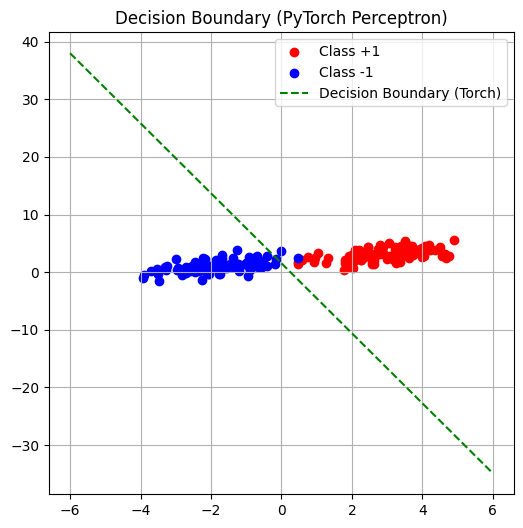

In [7]:
# Karar sınırını (decision boundary) çiz
x_vals = np.linspace(-6, 6, 100)   # X ekseni için 100 nokta (1D vektör)


# 5️⃣ PyTorch modeli için karar sınırını çiz (manuel versiyonla aynı formül)
# Tensörleri numpy dizilerine dönüştür
w_np = w_t.detach().numpy().flatten()  # (2,)
b_np = b_t.detach().numpy().flatten()  # (1,)

# Aynı karar sınırı formülü: y = -(w0*x + b)/w1
y_vals_torch = -(w_np[0]*x_vals + b_np) / w_np[1]

plt.figure(figsize=(6,6))
plt.scatter(X1[:,0], X1[:,1], c='r', label='Class +1')
plt.scatter(X2[:,0], X2[:,1], c='b', label='Class -1')
plt.plot(x_vals, y_vals_torch, 'g--', label='Decision Boundary (Torch)')
plt.title("Decision Boundary (PyTorch Perceptron)")
plt.legend()
plt.grid(True)
plt.show()

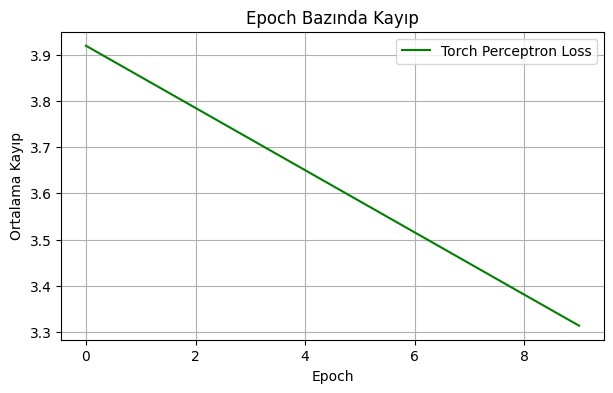

In [8]:
# 6️⃣ Modelin epoch bazında kayıplarını çiz
plt.figure(figsize=(7,4))
plt.plot(losses_torch, 'g-', label='Torch Perceptron Loss')
plt.title("Epoch Bazında Kayıp")
plt.xlabel("Epoch")
plt.ylabel("Ortalama Kayıp")
plt.legend()
plt.grid(True)
plt.show()